In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

cleaning data

In [60]:
train = pd.read_csv("train.csv")

print("Shape:", train.shape)
display(train.head())

print("\nMissing values:")
display(train.isnull().sum()[train.isnull().sum() > 0])

print("\nDuplicate rows:", train.duplicated().sum())

drop_cols = [
    "Id", "player_id", "player_name",
    "match_id", "match_date",
    "performance_score", "player_rating"
]





Shape: (43584, 75)


,Id,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,...,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards
0,M00001_P00053,P00053,Pedro Gavi,36,Spanish,Spain,1,Goalkeeper,191,80,...,50.8,0.0,38.6,28.6,31.4,65.4,0,0,67,0
1,M00001_P00054,P00054,Gavi Morata,27,Spanish,Spain,2,Goalkeeper,190,75,...,55.6,0.0,35.7,29.8,46.2,47.8,0,0,392,0
2,M00001_P00056,P00056,Pedro Torres,24,Spanish,Spain,4,Defender,176,78,...,70.5,6.4,52.7,31.3,68.3,59.2,0,0,324,0
3,M00001_P00058,P00058,Rodri Laporte,27,Spanish,Spain,6,Defender,188,80,...,85.6,6.4,48.7,15.3,61.8,55.1,0,1,264,0
4,M00001_P00060,P00060,Ferran Pau,35,Spanish,Spain,8,Defender,179,72,...,37.5,0.0,47.3,34.3,45.3,44.3,0,0,167,0



Missing values:


Series([], dtype: int64)


Duplicate rows: 0


Feature preparation

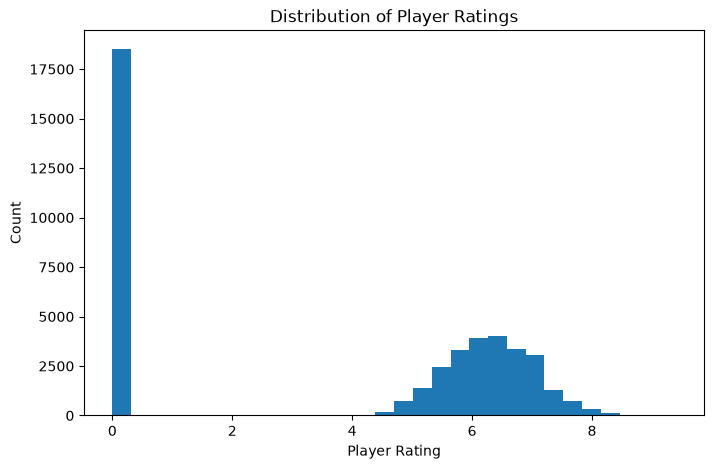

In [ ]:

plt.figure(figsize=(8,5))
plt.hist(train["player_rating"], bins=30)
plt.title("Distribution of Player Ratings")
plt.xlabel("Player Rating")
plt.ylabel("Count")
plt.show()

In [62]:

X = pd.get_dummies(train.drop(columns=drop_cols))
y = train["player_rating"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Training with Xgboost model

In [63]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    gamma=0.3,
    reg_alpha=0.3,
    reg_lambda=8,
    early_stopping_rounds=50,
    random_state=50
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Evaluating the model

In [64]:
train_pred = model.predict(X_train)
valid_pred = model.predict(X_valid)

print("Training MSE:", mean_squared_error(y_train, train_pred))


print("Validation MSE:", mean_squared_error(y_valid, valid_pred))

Training MSE: 0.20133394158694506
Validation MSE: 0.21593227039808552


MSE in training and validating are likely equal to each other then there is no high variance and no high bias

Now for the test.csv file

In [65]:
test = pd.read_csv("test.csv")

drop_cols_test = [
    "Id",
    "player_id",
    "player_name",
    "match_id",
    "match_date",
    "performance_score"
]

X_test = test.drop(columns=drop_cols_test)
X_test = pd.get_dummies(X_test)


X_test = X_test.reindex(columns=X.columns, fill_value=0)

In [66]:
predictions = model.predict(X_test)

submission = pd.DataFrame({
    "Id": test["Id"],
    "player_rating": predictions
})

submission.head()

,Id,player_rating
0,M00001_P00055,5.955835
1,M00001_P00057,0.003017
2,M00001_P00059,6.267163
3,M00001_P00064,0.001908
4,M00001_P00066,7.272515
